# Syndrome Lookup Tables for QEC Codes

Quantum error correction (QEC) protects a *logical* qubit against hardware noise by spreading its information across many *physical* qubits. Instead of directly measuring (and collapsing) the logical qubit, we periodically measure a set of carefully chosen parity checks — called **stabilizers** — on extra *ancilla* qubits. The measurement outcomes form a bit string called the **syndrome**.

Crucially, the syndrome tells us *something happened* without revealing the encoded information. A classical decoder then maps the observed syndrome to the most likely error, which we undo with a corresponding recovery operation.

In this notebook we build that classical decoder in its simplest form: a **lookup table** `syndrome → recovery` obtained by enumerating errors and computing their syndromes. Part 1 (below) treats the repetition code; later parts will extend the same pattern to the surface code.

## Part 1: Repetition Code

The `n`-qubit **repetition code** protects against single-qubit bit-flip (X) errors by encoding one logical qubit into `n` identical physical copies:

$$|0\rangle_L = |00\dots0\rangle,\qquad |1\rangle_L = |11\dots1\rangle.$$

Since the two logical states differ in every qubit, comparing neighboring qubits reveals whether something flipped. We add `m = n-1` ancilla qubits; ancilla `a_i` measures the parity $Z_iZ_{i+1}$ of data qubits `d_i` and `d_{i+1}`. If the two data qubits still agree, `a_i = 0`; if exactly one was flipped, `a_i = 1`. These `m` parity checks are the **stabilizer generators** of the code, and their outcomes form the length-`m` syndrome.

Because each ancilla touches only two neighboring data qubits, the code has a very visual structure: a 1-D chain.

### Tool 1: For visualize the code

n is the number of data qubits, and the number of ancilla qubits would be m=n-1.

The drawing convention used below:

- **Blue circles** (`d0, d1, …, d_{n-1}`) are data qubits — the physical qubits that hold the encoded logical state.
- **Red circles** (`a0, a1, …, a_{n-2}`) are ancilla qubits — extra qubits used only to measure the stabilizers.
- **Gray lines** connect each ancilla to the two data qubits it measures. In other words, each line indicates a CNOT in the syndrome extraction circuit (data qubit as control, ancilla as target). Ancilla `a_i` has two incident lines going to `d_i` and `d_{i+1}`, so measuring `a_i` reveals the parity $Z_iZ_{i+1}$. These lines are the analog of the "edges" in a Tanner graph of the code. The discussion syndrome extraction circuit is out of scope for this notebook, and will be discussed elsewhere.


In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def visualize_repetition_code(n, radius=0.25, line_width=1.5):
    fig, ax = plt.subplots(figsize=(1.4 * n, 2.8))
    data_pos = [(i, 0) for i in range(n)]
    anc_pos = [(i + 0.5, 1) for i in range(n - 1)]
    # edges first so circles sit on top
    for i, (x, y) in enumerate(anc_pos):
        ax.plot([data_pos[i][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
        ax.plot([data_pos[i + 1][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
    for i, (x, y) in enumerate(data_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#1f77b4", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"d{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    for i, (x, y) in enumerate(anc_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#d62728", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"a{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    ax.set_xlim(-0.7, n - 0.3); ax.set_ylim(-0.6, 1.6)
    ax.set_aspect("equal"); ax.axis("off")
    plt.show()

### Tool 2: Print the stabilizer generators

The repetition code that protects against bit-flip (X) errors is stabilized by **Z-type** operators of the form $S_i = Z_iZ_{i+1}$ for $i = 0, 1, \dots, n-2$. There are exactly `m = n-1` generators, matching the `m` ancilla qubits. Each generator commutes with the logical operators $\bar{X} = X_0 X_1 \cdots X_{n-1}$ and $\bar{Z} = Z_0$. The choice of $\bar Z$ is not unique, and in fact any $Z_i$ is a valid logical Z operator.

Z-type stabilizers anti-commute with X errors, so measuring them detects **X (bit-flip) errors** — this is why our lookup maps a *Z* syndrome to a set of *X* error patterns.

In [14]:
def stabilizer_generators(n):
    gens = []
    for i in range(n - 1):
        g = ["I"] * n
        g[i] = g[i + 1] = "Z"
        gens.append("".join(g))
    return gens

def print_stabilizer_generators(n):
    for i, g in enumerate(stabilizer_generators(n)):
        print(f"S{i} = {g}")

### Tool 3: Build the lookup table ($2^{m}$ entries, $m=n-1$)

Enumerate all $2^n$ X-error patterns and group them by their syndrome. The lookup table has syndrome as keys, with value being the **full list** of X-error patterns consistent with that syndrome, sorted by Hamming weight (lowest first).

A few things worth understanding about this table:

1. **Why $2^m$ entries?** The full `n`-qubit Hilbert space is $2^n$-dimensional, while the code (the logical qubit) lives in a $2$-dimensional subspace — the joint $+1$ eigenspace of all `m = n-1` stabilizers. The $2^m$ possible syndrome values partition the full Hilbert space into $2^m$ orthogonal subspaces, each $2^n / 2^m = 2$-dimensional (one logical qubit's worth). Every possible error maps the code into exactly one of these subspaces, so a complete decoder must assign a recovery to every one of the $2^m$ syndromes.

2. **Why do multiple errors share a syndrome?** The code has $2^n$ possible X-error patterns but only $2^m = 2^{n-1}$ syndromes, so *exactly two* distinct X-error patterns produce each syndrome. They always differ by the logical operator `L = X⊗X⊗…⊗X`: if `E` gives syndrome `s`, then `E ⊕ L` gives the same `s` because `L` commutes with every stabilizer. The decoder cannot distinguish these two from the syndrome alone — that is precisely why the code has a finite error-correction threshold.

3. **Minimum-weight decoding.** In practice a decoder needs to *pick one* recovery. Assuming each physical qubit has an independent small flip probability, the most likely error is the one with the **fewest** flips — the first entry in each sorted list. Correct recovery is guaranteed for any error of weight $\le \lfloor (n-1)/2 \rfloor$; beyond that, the decoder may pick the wrong coset representative, causing a logical error. Note that minimum-weight decoding is NOT the optimal decoding method, and the discussion of latter is out of scope of this notebook, and will be discussed elsewhere.

In [15]:
from itertools import combinations

def syndrome_of(n, error):
    e = [0] * n
    for q in error:
        e[q] ^= 1
    return tuple(e[i] ^ e[i + 1] for i in range(n - 1))

def build_lookup_table(n):
    lookup = {}
    for w in range(n + 1):
        for err in combinations(range(n), w):
            lookup.setdefault(syndrome_of(n, err), []).append(err)
    return lookup

### example 1: n=2

There are $2^1 = 2$ syndromes and 4 error patterns. Syndrome `(0,)` is produced by both `()` and `(0, 1)` (no flip or both flipped); syndrome `(1,)` is produced by both `(0,)` and `(1,)` (flip the first or the second qubit). Seeing both options makes the ambiguity explicit.

When you read the printed table, each syndrome now lists **all** error patterns consistent with it (sorted by weight). 

For $n=2$, it is a error **detection** code, because for the nontrivial syndrome, the two error patterns have the same weight, hence we can't determine which recovery to correct the error.

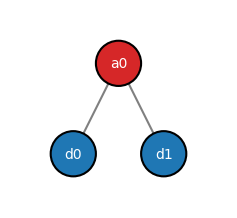

Z-type stabilizer generators (1):
S0 = ZZ

number of entries: 2 (= 2^1)
Z syndrome (0,) -> X errors [(), (0, 1)]
Z syndrome (1,) -> X errors [(0,), (1,)]


In [16]:
n = 2  # number of data qubits
m = n - 1  # number of ancilla qubits
visualize_repetition_code(n)

print(f"Z-type stabilizer generators ({m}):")
print_stabilizer_generators(n)
print()

lookup = build_lookup_table(n)
print(f"number of entries: {len(lookup)} (= 2^{m})")
for s, e in sorted(lookup.items()):
    print(f"Z syndrome {s} -> X errors {e}")

### example 2: n=3

Take the syndrome `(0, 1)` as an example. The two listed errors are `(2,)` and `(0, 1)`. These are X on qubit 2 versus X on qubits 0 and 1 — i.e. `IIX` vs `XXI`. Their product is `IIX · XXI = XXX`, which is the **logical X operator** $\bar X$. Since we have assumed that each physical qubit has an independent small flip probability, from this syndrome, our best guess of the most likely error would be `IIX`. Hence, we pick `IIX` as the recovery, meaning we apply the operator `IIX` on the three data qubits. Now let us what happened in two cases. 
   - If the true error is `(2,)` (weight 1) and the selected recovery `IIX` undo it exactly → no logical error.
   - If the true error is `(0, 1)` (weight 2) and the net result of the true error AND our recovery would be `IIX · XXI = XXX = \bar X` → the logical qubit is *flipped* (a logical error).

The decoder cannot tell these two cases apart from the syndrome alone; it picks the most likely one (weight 1). This is why the `n = 3` repetition code corrects only weight-1 errors: once two qubits flip, the guess becomes wrong.

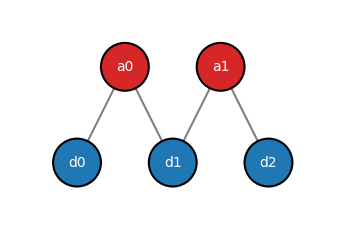

Z-type stabilizer generators (2):
S0 = ZZI
S1 = IZZ

number of entries: 4 (= 2^2)
Z syndrome (0, 0) -> X errors [(), (0, 1, 2)]
Z syndrome (0, 1) -> X errors [(2,), (0, 1)]
Z syndrome (1, 0) -> X errors [(0,), (1, 2)]
Z syndrome (1, 1) -> X errors [(1,), (0, 2)]


In [17]:
n = 3  # number of data qubits
m = n - 1  # number of ancilla qubits
visualize_repetition_code(n)

print(f"Z-type stabilizer generators ({m}):")
print_stabilizer_generators(n)
print()

lookup = build_lookup_table(n)
print(f"number of entries: {len(lookup)} (= 2^{m})")
for s, e in sorted(lookup.items()):
    print(f"Z syndrome {s} -> X errors {e}")

## Part 2: Unrotated Surface Code

The **unrotated surface code** (also known as the planar code) is a topological CSS code defined on a 2D lattice with open boundaries. It encodes a single logical qubit and has code distance `d` (where `d` is a tunable parameter, $d\ge2$). Compared to the repetition code, it protects against *both* bit-flip (X) and phase-flip (Z) errors — but the workflow for building a syndrome lookup table is exactly the same as Part 1, applied independently to the X and Z sectors.

The formal description of the layout of the surface code is the following, which could be confusing. The easiest way is to look at the visualization below.

Layout:
- **Data qubits** live on the edges of a $d\times d$ vertex lattice. There are $n = d^2 + (d-1)^2$ of them, arranged in alternating "long" rows of $d$ qubits and "short" rows of $d-1$ qubits (total $2d-1$ rows).
- **Z-type stabilizers** $S^Z = \prod_{i\in S} Z_i$ are plaquette-like operators that detect X errors. They act on 3 qubits near the left/right boundaries and on 4 qubits in the bulk.
- **X-type stabilizers** $S^X = \prod_{i\in S} X_i$ are vertex-like operators that detect Z errors. They act on 3 qubits near the top/bottom boundaries and on 4 qubits in the bulk.
- There are $m = d(d-1)$ stabilizers of each type, so $2m = 2d(d-1)$ ancillas total.
- Logical operators: $\bar{X}$ is a string of X on the bottom row of data qubits; $\bar{Z}$ is a string of Z down the left column. Both have weight $d$, which is the code distance.

### Tool 1: Visualize the code

In [18]:
def surface_Z_stabilizers(d):
    out = []
    for i in range(1, d):  # left boundary
        out.append(sorted([i - 1, i, i + d - 1]))
    for i in range(1, d):  # right boundary
        base = (2 * d - 1) * (d - 1) + i
        out.append(sorted([base - d, base - 1, base]))
    for i in range(1, d):  # bulk
        for j in range(1, d - 1):
            shift = (i - 1) + (2 * d - 1) * (j - 1) - 1
            out.append(sorted([d + 1 + shift, 2 * d + shift, 2 * d + 1 + shift, 3 * d + shift]))
    return out

def surface_X_stabilizers(d):
    out = []
    for i in range(1, d):  # top boundary
        out.append(sorted([(2 * d - 1) * (i - 1), (2 * d - 1) * (i - 1) + d, (2 * d - 1) * i]))
    for i in range(1, d):  # bottom boundary
        out.append(sorted([d + (2 * d - 1) * (i - 1) - 1, d + (2 * d - 1) * (i - 1) + d - 2, d + (2 * d - 1) * i - 1]))
    for i in range(1, d - 1):  # bulk
        for j in range(1, d):
            b = i + (j - 1) * (2 * d - 1)
            out.append(sorted([b, b + d - 1, b + d, b + (2 * d - 1)]))
    return out


def data_positions(d):
    """(x, y) for each of the n = d^2 + (d-1)^2 data qubits on a (2d-1)x(2d-1) integer grid."""
    pos = []
    for row in range(2 * d - 1):
        if row % 2 == 0:
            for c in range(d):
                pos.append((2 * c, -row))
        else:
            for c in range(d - 1):
                pos.append((2 * c + 1, -row))
    return pos

def _ancilla_position(support, dpos):
    """Grid point adjacent (L1 distance 1) to every data qubit in the stabilizer's support."""
    cands = set()
    for q in support:
        x, y = dpos[q]
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            cands.add((x + dx, y + dy))
    for cand in cands:
        if all(abs(cand[0] - dpos[q][0]) + abs(cand[1] - dpos[q][1]) == 1 for q in support):
            return cand
    raise ValueError("no valid ancilla position")

def visualize_surface_code(d, radius=0.35, line_width=3.0, fontsize=12):
    dpos = data_positions(d)
    size = 1.2 * (2 * d - 1)
    fig, axes = plt.subplots(1, 2, figsize=(2 * size, size))
    panels = [
        (axes[0], [(surface_Z_stabilizers(d), "#2ca02c", "z"), (surface_X_stabilizers(d), "#d62728", "x")], "All stabilizers"),
        (axes[1], [(surface_X_stabilizers(d), "#d62728", "x")], "X-type stabilizers only"),
    ]
    for ax, stab_groups, title in panels:
        for stabs, color, prefix in stab_groups:
            for k, s in enumerate(stabs):
                cx, cy = _ancilla_position(s, dpos)
                for q in s:
                    ax.plot([dpos[q][0], cx], [dpos[q][1], cy], color="gray", linewidth=line_width, zorder=1)
                ax.add_patch(Circle((cx, cy), radius, facecolor=color, edgecolor="black", linewidth=line_width, zorder=2))
                ax.text(cx, cy, f"{prefix}{k}", ha="center", va="center", color="white", fontsize=fontsize, zorder=3)
        for i, (x, y) in enumerate(dpos):
            ax.add_patch(Circle((x, y), radius, facecolor="#1f77b4", edgecolor="black", linewidth=line_width, zorder=3))
            ax.text(x, y, f"d{i}", ha="center", va="center", color="white", fontsize=fontsize, zorder=4)
        ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)
    plt.show()

#### Quick visualization of a d=3 surface code
- **Blue circles**: data qubits, labelled `0, 1, ..., n-1` in row-major order (left-to-right, top-to-bottom).
- **Red circles**: X-type stabilizer ancillas (detect Z errors). Located at the centroid of the data qubits they couple to.
- **Green circles**: Z-type stabilizer ancillas (detect X errors). Same convention.
- **Gray lines**: Each line indicates that a stabilizer acts on the connected data qubit. Boundary stabilizers have 3 lines; bulk stabilizers have 4.

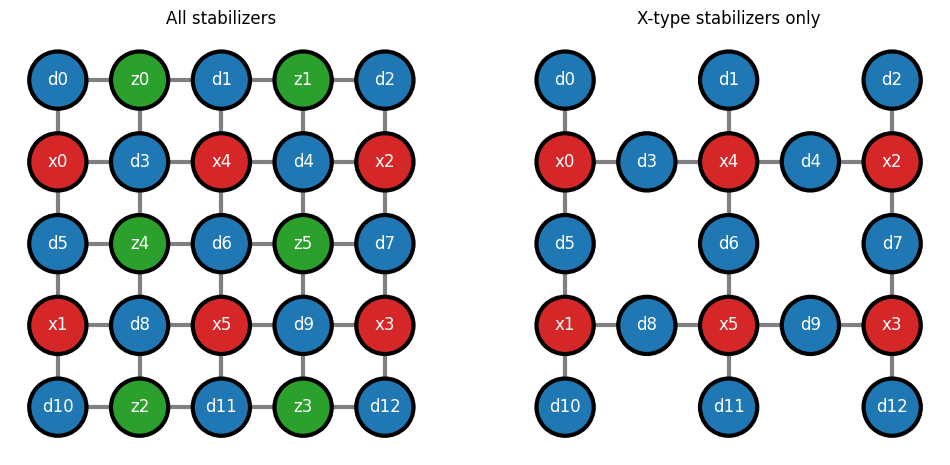

In [19]:
d=3
visualize_surface_code(d)

### Tool 2: Print the stabilizer generators

Each stabilizer is defined by its support — the list of data-qubit indices it acts on. `print_surface_stabilizer_generators` renders them as Pauli strings over all `n` qubits for readability.

In [20]:
def _pauli_string(n, support, letter):
    s = ["I"] * n
    for q in support:
        s[q] = letter
    return "".join(s)

def print_surface_stabilizer_generators(d):
    n = d * d + (d - 1) ** 2
    for i, s in enumerate(surface_Z_stabilizers(d)):
        print(f"SZ{i} = {_pauli_string(n, s, 'Z')}  (support {s})")
    for i, s in enumerate(surface_X_stabilizers(d)):
        print(f"SX{i} = {_pauli_string(n, s, 'X')}  (support {s})")

### Tool 3: Build the lookup tables

The unrotated surface code is a CSS code, which means X and Z errors are decoded independently:

- **Z-syndrome → X-error lookup**: measuring the $m = d(d-1)$ Z-stabilizers gives a length-$m$ bit string; we map it to the list of all consistent X-error patterns.
- **X-syndrome → Z-error lookup**: symmetrically, measuring the $m$ X-stabilizers produces a Z-error lookup.

Each table has exactly $2^m$ entries, and each entry holds $2^n / 2^m = 2^{n-m}$ error patterns (all related to each other by products of stabilizers and the logical operator of the relevant type). The construction enumerates errors in order of increasing weight so the first entry in each list is the minimum-weight representative (the standard recovery).

**Complexity warning:** enumeration is $O(2^n)$, so this is only feasible for small $d$ (e.g. $d=2$ with $n=5$, or $d=3$ with $n=13$). Larger codes require proper decoders like minimum-weight perfect matching.

In [21]:
def syndrome_from_stabilizers(n, error, stabilizers):
    e = [0] * n
    for q in error:
        e[q] ^= 1
    return tuple(sum(e[q] for q in s) % 2 for s in stabilizers)

def build_surface_lookup(d, kind):
    """kind='X' -> Z-syndrome -> X-error table; kind='Z' -> X-syndrome -> Z-error table."""
    n = d * d + (d - 1) ** 2
    stabs = surface_Z_stabilizers(d) if kind == "X" else surface_X_stabilizers(d)
    lookup = {}
    for w in range(n + 1):
        for err in combinations(range(n), w):
            lookup.setdefault(syndrome_from_stabilizers(n, err, stabs), []).append(err)
    return lookup

### Example 1: d=2

The smallest unrotated surface code: $n = 4 + 1 = 5$ data qubits, $m = 2$ stabilizers of each type. Each sector has $2^2 = 4$ syndromes and each lookup entry holds $2^{5-2} = 8$ consistent errors. Like the $n=2$ repetition code, distance $d=2$ is a pure error-**detection** code.

For example, when the Z syndrome is (0, 1), the most likely errors are $X_3$ and $X_4$, see below. We can't determine which one is actually more likely to happen, and $X_3X_4$ is the logical $X$ operator, meaning that if randomly pick either $X_3$ and $X_4$ as our recovery, it is like flipping a coin to determine if to apply the logical $X$ operator. 

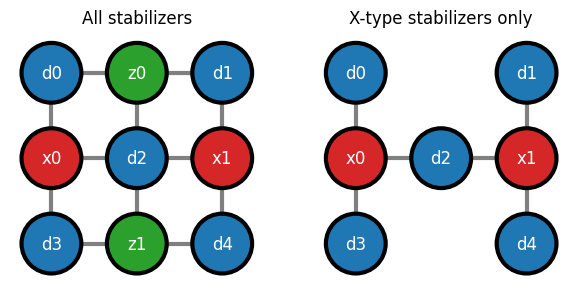

n = 5 data qubits, m = 2 stabilizers of each type

stabilizer generators:
SZ0 = ZZZII  (support [0, 1, 2])
SZ1 = IIZZZ  (support [2, 3, 4])
SX0 = XIXXI  (support [0, 2, 3])
SX1 = IXXIX  (support [1, 2, 4])

Z-syndrome -> X-error lookup (4 entries = 2^2):
  Z syndrome (0, 0) -> X errors [(), (0, 1), (3, 4), (0, 2, 3), (0, 2, 4), (1, 2, 3), (1, 2, 4), (0, 1, 3, 4)]
  Z syndrome (0, 1) -> X errors [(3,), (4,), (0, 2), (1, 2), (0, 1, 3), (0, 1, 4), (0, 2, 3, 4), (1, 2, 3, 4)]
  Z syndrome (1, 0) -> X errors [(0,), (1,), (2, 3), (2, 4), (0, 3, 4), (1, 3, 4), (0, 1, 2, 3), (0, 1, 2, 4)]
  Z syndrome (1, 1) -> X errors [(2,), (0, 3), (0, 4), (1, 3), (1, 4), (0, 1, 2), (2, 3, 4), (0, 1, 2, 3, 4)]

X-syndrome -> Z-error lookup (4 entries = 2^2):
  X syndrome (0, 0) -> Z errors [(), (0, 3), (1, 4), (0, 1, 2), (0, 2, 4), (1, 2, 3), (2, 3, 4), (0, 1, 3, 4)]
  X syndrome (0, 1) -> Z errors [(1,), (4,), (0, 2), (2, 3), (0, 1, 3), (0, 3, 4), (0, 1, 2, 4), (1, 2, 3, 4)]
  X syndrome (1, 0) -> Z errors

In [22]:
d = 2
n_surf = d * d + (d - 1) ** 2
m_surf = d * (d - 1)
visualize_surface_code(d)

print(f"n = {n_surf} data qubits, m = {m_surf} stabilizers of each type\n")
print("stabilizer generators:")
print_surface_stabilizer_generators(d)
print()

lookup_X = build_surface_lookup(d, kind="X")
print(f"Z-syndrome -> X-error lookup ({len(lookup_X)} entries = 2^{m_surf}):")
for s, e in sorted(lookup_X.items()):
    print(f"  Z syndrome {s} -> X errors {e}")
print()

lookup_Z = build_surface_lookup(d, kind="Z")
print(f"X-syndrome -> Z-error lookup ({len(lookup_Z)} entries = 2^{m_surf}):")
for s, e in sorted(lookup_Z.items()):
    print(f"  X syndrome {s} -> Z errors {e}")

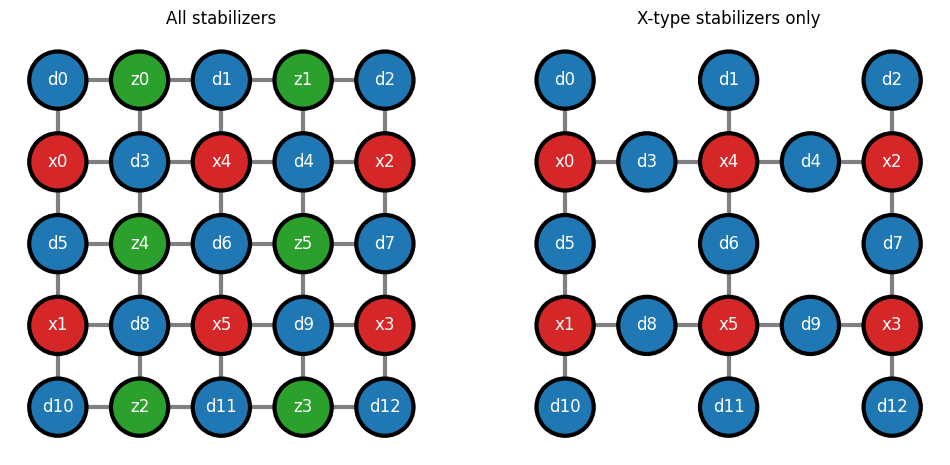

X-syndrome -> Z-error lookup (64 entries = 2^6):
  X syndrome (0, 0, 0, 0, 0, 0) -> Z errors [(), (0, 1, 3), (0, 5, 10), (1, 2, 4), (1, 6, 11), (2, 7, 12), (8, 10, 11), (9, 11, 12), (0, 2, 3, 4), (0, 3, 6, 11), (0, 5, 8, 11), (1, 3, 5, 10), (1, 4, 7, 12), (1, 6, 8, 10), (1, 6, 9, 12), (2, 4, 6, 11), (2, 7, 9, 11), (3, 5, 6, 8), (4, 6, 7, 9), (8, 9, 10, 12), (0, 1, 5, 6, 8), (0, 3, 4, 7, 12), (0, 3, 6, 8, 10), (0, 3, 6, 9, 12), (0, 5, 8, 9, 12), (1, 2, 6, 7, 9), (1, 3, 5, 8, 11), (1, 4, 7, 9, 11), (2, 3, 4, 5, 10), (2, 4, 6, 8, 10), (2, 4, 6, 9, 12), (2, 7, 8, 9, 10), (3, 5, 6, 10, 11), (4, 6, 7, 11, 12), (0, 1, 2, 3, 7, 12), (0, 1, 2, 4, 5, 10), (0, 1, 3, 8, 10, 11), (0, 1, 3, 9, 11, 12), (0, 1, 5, 6, 10, 11), (0, 2, 3, 6, 7, 9), (0, 2, 4, 5, 6, 8), (0, 2, 5, 7, 8, 9), (0, 2, 5, 7, 10, 12), (0, 3, 4, 7, 9, 11), (0, 5, 9, 10, 11, 12), (1, 2, 4, 8, 10, 11), (1, 2, 4, 9, 11, 12), (1, 2, 6, 7, 11, 12), (1, 3, 5, 8, 9, 12), (1, 4, 7, 8, 9, 10), (2, 3, 4, 5, 8, 11), (2, 7, 8, 10, 11, 12), (3

In [23]:
d = 3
n_surf = d * d + (d - 1) ** 2
m_surf = d * (d - 1)
visualize_surface_code(d)

# print(f"n = {n_surf} data qubits, m = {m_surf} stabilizers of each type\n")
# print("stabilizer generators:")
# print_surface_stabilizer_generators(d)
# print()

# lookup_X = build_surface_lookup(d, kind="X")
# print(f"Z-syndrome -> X-error lookup ({len(lookup_X)} entries = 2^{m_surf}):")
# for s, e in sorted(lookup_X.items()):
#     print(f"  Z syndrome {s} -> X errors {e}")
# print()

lookup_Z = build_surface_lookup(d, kind="Z")
print(f"X-syndrome -> Z-error lookup ({len(lookup_Z)} entries = 2^{m_surf}):")
for s, e in sorted(lookup_Z.items()):
    print(f"  X syndrome {s} -> Z errors {e}")

#### Another way to show the same look up table by showing which syndrome a single X error would trigger

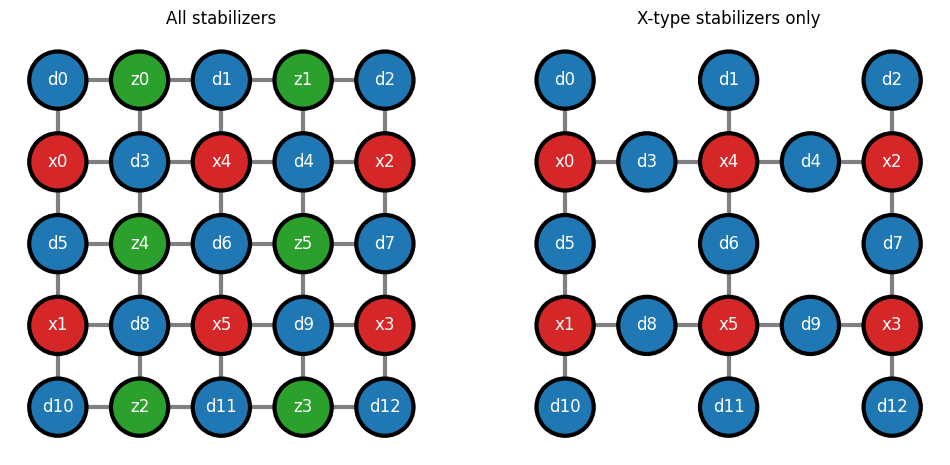

single-qubit X errors and their Z syndromes (m=6):
  X on qubit 0: Z syndrome (1, 0, 0, 0, 0, 0)
  X on qubit 1: Z syndrome (1, 1, 0, 0, 0, 0)
  X on qubit 2: Z syndrome (0, 1, 0, 0, 0, 0)
  X on qubit 3: Z syndrome (1, 0, 0, 0, 1, 0)
  X on qubit 4: Z syndrome (0, 1, 0, 0, 0, 1)
  X on qubit 5: Z syndrome (0, 0, 0, 0, 1, 0)
  X on qubit 6: Z syndrome (0, 0, 0, 0, 1, 1)
  X on qubit 7: Z syndrome (0, 0, 0, 0, 0, 1)
  X on qubit 8: Z syndrome (0, 0, 1, 0, 1, 0)
  X on qubit 9: Z syndrome (0, 0, 0, 1, 0, 1)
  X on qubit 10: Z syndrome (0, 0, 1, 0, 0, 0)
  X on qubit 11: Z syndrome (0, 0, 1, 1, 0, 0)
  X on qubit 12: Z syndrome (0, 0, 0, 1, 0, 0)


In [24]:
d = 3
n_surf = d * d + (d - 1) ** 2
m_surf = d * (d - 1)
visualize_surface_code(d)

# print(f"n = {n_surf} data qubits, m = {m_surf} stabilizers of each type\n")
# print("stabilizer generators:")
# print_surface_stabilizer_generators(d)
# print()

Zs = surface_Z_stabilizers(d)
print(f"single-qubit X errors and their Z syndromes (m={m_surf}):")
for q in range(n_surf):
    s = syndrome_from_stabilizers(n_surf, (q,), Zs)
    print(f"  X on qubit {q}: Z syndrome {s}")